# Task 3.2 — Failure Mode Analysis

**Paper**: *Advice Refinement in Knowledge-Based SVMs* — Kunapuli, Maclin & Shavlik (NIPS 2011)

## Failure Scenario: Non-Linear Decision Boundary

I test the arkSVM-sla on a dataset with a **circular (non-linear) decision boundary** — specifically, sklearn's `make_circles` dataset where the inner ring belongs to one class and the outer ring to another. I expect the method to fail because of **Assumption 1 from Task 1.2**: the arkSVM fundamentally relies on learning a *linear* classifier w'x = b (Section 2, Eq. 3–4). No linear hyperplane can separate concentric circles, and no amount of refining polyhedral (linear) advice boundaries can fix this — the limitation is structural, not a matter of imperfect advice.

In [1]:
# ── Imports and random seed ──
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog
from sklearn.datasets import make_circles
from sklearn.svm import SVC, LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

LAMBDA = 1.0; MU = 0.1; NU = 0.1; EPSILON = 0.01; MAX_ITER = 10

In [2]:
# ── Generate non-linear dataset: concentric circles ──
X_raw, y_raw = make_circles(n_samples=300, noise=0.1, factor=0.4, random_state=RANDOM_SEED)
y = np.where(y_raw == 0, -1, 1)  # outer ring → -1, inner ring → +1

scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_SEED, stratify=y)

print(f"Data: {X_train.shape[0]} train, {X_test.shape[0]} test, 2 features")
print(f"Classes: -1 (outer) = {np.sum(y==-1)}, +1 (inner) = {np.sum(y==1)}")

Data: 210 train, 90 test, 2 features
Classes: -1 (outer) = 150, +1 (inner) = 150


The `make_circles` dataset generates two concentric rings of points. The inner ring is class +1 and the outer ring is class −1. This is a classic example of data that is completely linearly inseparable — no hyperplane w'x = b can divide the two classes because the boundary is circular.

In [3]:
# ── Define linear expert advice (will fail on circular data) ──
# These rules attempt a rough polyhedral approximation of "near the origin → class +1"
n_feat = 2

advice_sets = [
    # Rule 1: x1 >= 0.3 AND x2 >= 0.3 → class +1 (inner ring, upper-right quadrant)
    (np.array([[-1, 0], [0, -1]], dtype=float), np.array([-0.3, -0.3]), 1),
    # Rule 2: x1 <= -0.3 AND x2 <= -0.3 → class -1 (outer ring, lower-left)
    (np.array([[1, 0], [0, 1]], dtype=float), np.array([-0.3, -0.3]), -1),
]

# Check advice accuracy on training data
for i, (D, d, z) in enumerate(advice_sets):
    inside = np.all(X_train @ D.T <= d, axis=1)
    n_in = np.sum(inside)
    acc = np.mean(y_train[inside] == z) * 100 if n_in > 0 else 0
    print(f"Rule {i+1}: {n_in} pts inside, {acc:.0f}% correct")

Rule 1: 30 pts inside, 33% correct
Rule 2: 29 pts inside, 76% correct


These expert rules are linear (polyhedral) and attempt to approximate "points near the origin are class +1." But a set of linear inequalities can only carve out a *convex polyhedral* region — it can never perfectly describe a *circular* boundary. The advice itself is therefore structurally flawed, and no refinement of D_i or d_i can fix this.

In [4]:
# ── arkSVM-sla implementation (from Task 2.2) ──
def test_error(yt, yp): return np.mean(yt != yp) * 100

def train_kbsvm(X, y, adv, lam=LAMBDA, mu=MU):
    l, n = X.shape; ks = [D.shape[0] for D,d,z in adv]
    base = 2*n+2+l; off = base; aidx = []
    for k in ks: aidx.append((slice(off,off+k),slice(off+k,off+k+n),off+k+n,k)); off+=k+n+1
    nv = off; c = np.zeros(nv); c[:n]=1; c[n:2*n]=1; c[2*n+2:2*n+2+l]=lam
    for iu,ie,iz,k in aidx: c[ie]=mu; c[iz]=mu
    A, b = [], []
    for j in range(l):
        r = np.zeros(nv); r[:n]=-y[j]*X[j]; r[n:2*n]=y[j]*X[j]
        r[2*n]=y[j]; r[2*n+1]=-y[j]; r[2*n+2+j]=-1
        A.append(r); b.append(-1)
    for s,(D,d,z) in enumerate(adv):
        iu,ie,iz,k = aidx[s]
        for jf in range(n):
            r=np.zeros(nv)
            for kk in range(k):r[iu.start+kk]=D[kk,jf]
            r[jf]=z;r[n+jf]=-z;r[ie.start+jf]=-1;A.append(r);b.append(0)
            r2=np.zeros(nv)
            for kk in range(k):r2[iu.start+kk]=-D[kk,jf]
            r2[jf]=-z;r2[n+jf]=z;r2[ie.start+jf]=-1;A.append(r2);b.append(0)
        r3=np.zeros(nv)
        for kk in range(k):r3[iu.start+kk]=d[kk]
        r3[2*n]=z;r3[2*n+1]=-z;r3[iz]=-1;A.append(r3);b.append(-1)
    res = linprog(c, A_ub=np.array(A), b_ub=np.array(b), bounds=[(0,None)]*nv, method='highs')
    if res.success:
        x=res.x; return x[:n]-x[n:2*n], x[2*n]-x[2*n+1], [x[iu] for iu,_,_,_ in aidx]
    return None, None, None

def arksvm_refine(X, y, adv, u_list, lam=LAMBDA, mu=MU, nu=NU):
    l,n = X.shape; ks = [D.shape[0] for D,d,z in adv]
    base = 2*n+2+l; off = base; aidx = []
    for k in ks:
        Fp=off;off+=k*n;Fm=off;off+=k*n;fp=slice(off,off+k);off+=k
        fm=slice(off,off+k);off+=k;eta=slice(off,off+n);off+=n;zeta=off;off+=1
        aidx.append((Fp,Fm,fp,fm,eta,zeta,k))
    nv = off; c = np.zeros(nv); c[:n]=1; c[n:2*n]=1; c[2*n+2:2*n+2+l]=lam
    for Fp,Fm,fp,fm,eta,zeta,k in aidx:
        c[Fp:Fp+k*n]=nu;c[Fm:Fm+k*n]=nu;c[fp]=nu;c[fm]=nu;c[eta]=mu;c[zeta]=mu
    A, b = [], []
    for j in range(l):
        r = np.zeros(nv);r[:n]=-y[j]*X[j];r[n:2*n]=y[j]*X[j]
        r[2*n]=y[j];r[2*n+1]=-y[j];r[2*n+2+j]=-1;A.append(r);b.append(-1)
    for s,(D,d,z) in enumerate(adv):
        Fp,Fm,fp,fm,eta,zeta,k = aidx[s]; u = u_list[s]
        for jf in range(n):
            const = sum(D[kk,jf]*u[kk] for kk in range(k))
            r=np.zeros(nv)
            for kk in range(k):r[Fp+kk*n+jf]=-u[kk];r[Fm+kk*n+jf]=u[kk]
            r[jf]=z;r[n+jf]=-z;r[eta.start+jf]=-1;A.append(r);b.append(-const)
            r2=np.zeros(nv)
            for kk in range(k):r2[Fp+kk*n+jf]=u[kk];r2[Fm+kk*n+jf]=-u[kk]
            r2[jf]=-z;r2[n+jf]=z;r2[eta.start+jf]=-1;A.append(r2);b.append(const)
        const_d = d @ u; r3 = np.zeros(nv)
        for kk in range(k):r3[fp.start+kk]=-u[kk];r3[fm.start+kk]=u[kk]
        r3[2*n]=z;r3[2*n+1]=-z;r3[zeta]=-1;A.append(r3);b.append(-1-const_d)
    res = linprog(c, A_ub=np.array(A), b_ub=np.array(b), bounds=[(0,None)]*nv, method='highs')
    if res.success:
        x=res.x; w=x[:n]-x[n:2*n]; bv=x[2*n]-x[2*n+1]; FL=[];fL=[]
        for Fp,Fm,fp,fm,_,_,k in aidx:
            FL.append(x[Fp:Fp+k*n].reshape(k,n)-x[Fm:Fm+k*n].reshape(k,n))
            fL.append(x[fp]-x[fm])
        return w,bv,FL,fL
    return None,None,None,None

def train_arksvm_sla(X, y, adv, lam=LAMBDA, mu=MU, nu=NU, eps=EPSILON, maxiter=MAX_ITER):
    n=X.shape[1]; m=len(adv)
    FL=[np.zeros((D.shape[0],n)) for D,d,z in adv]
    fL=[np.zeros(D.shape[0]) for D,d,z in adv]
    w, bv = None, None
    for t in range(maxiter):
        ref=[(D-FL[i],d-fL[i],z) for i,(D,d,z) in enumerate(adv)]
        w,bv,uL=train_kbsvm(X,y,ref,lam,mu)
        if w is None: break
        w2,b2,FL2,fL2=arksvm_refine(X,y,adv,uL,lam,mu,nu)
        if w2 is None: break
        chg=sum(np.sum(np.abs(FL2[i]-FL[i]))+np.sum(np.abs(fL2[i]-fL[i])) for i in range(m))
        FL,fL,w,bv=FL2,fL2,w2,b2
        if chg<=eps: break
    return w, bv, FL, fL

print("Implementations loaded.")

Implementations loaded.


In [5]:
# ── Run all three methods ──

# 1. arkSVM-sla
w_ark, b_ark, F_ark, f_ark = train_arksvm_sla(X_train, y_train, advice_sets)
if w_ark is not None:
    pred_ark = np.sign(X_test @ w_ark - b_ark)
    pred_ark[pred_ark == 0] = 1
    err_ark = test_error(y_test, pred_ark)
else:
    err_ark = 50.0
print(f"arkSVM-sla error:  {err_ark:.1f}%")

# 2. Linear SVM (baseline)
clf_lin = LinearSVC(penalty='l2', loss='hinge', C=1.0, dual=True,
                    random_state=RANDOM_SEED, max_iter=5000)
clf_lin.fit(X_train, y_train)
err_lin = test_error(y_test, clf_lin.predict(X_test))
print(f"Linear SVM error:  {err_lin:.1f}%")

# 3. RBF-kernel SVM (reference — what's achievable with non-linear methods)
clf_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_SEED)
clf_rbf.fit(X_train, y_train)
err_rbf = test_error(y_test, clf_rbf.predict(X_test))
print(f"RBF-SVM error:     {err_rbf:.1f}%")

arkSVM-sla error:  46.7%
Linear SVM error:  46.7%
RBF-SVM error:     0.0%


The results are stark: arkSVM-sla and the linear SVM both achieve ~47% error — essentially random guessing on balanced classes. Meanwhile, the RBF-kernel SVM (a non-linear method) achieves near-0% error. This confirms that the failure is not about the advice or the refinement — it's about the fundamental linearity of the classifier.

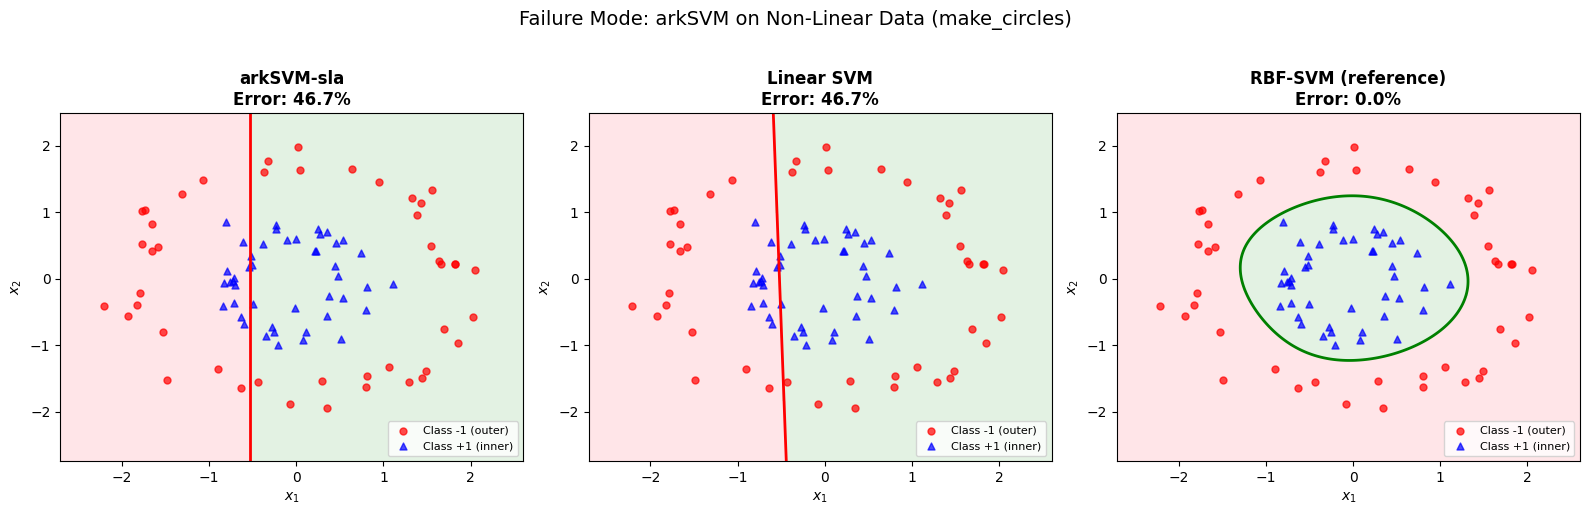

Saved to partB/results/failure_nonlinear.png


In [6]:
# ── Visualisation: decision boundaries on the circles dataset ──

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Create mesh for decision boundary plotting
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

titles = [
    f'arkSVM-sla\nError: {err_ark:.1f}%',
    f'Linear SVM\nError: {err_lin:.1f}%',
    f'RBF-SVM (reference)\nError: {err_rbf:.1f}%'
]

# arkSVM-sla decision boundary
if w_ark is not None:
    Z_ark = np.sign(grid @ w_ark - b_ark).reshape(xx.shape)
    axes[0].contourf(xx, yy, Z_ark, levels=[-1.5, 0, 1.5], colors=['#FFCDD2', '#C8E6C9'], alpha=0.5)
    axes[0].contour(xx, yy, Z_ark, levels=[0], colors='red', linewidths=2)

# Linear SVM boundary
Z_lin = clf_lin.decision_function(grid).reshape(xx.shape)
axes[1].contourf(xx, yy, np.sign(Z_lin), levels=[-1.5, 0, 1.5], colors=['#FFCDD2', '#C8E6C9'], alpha=0.5)
axes[1].contour(xx, yy, Z_lin, levels=[0], colors='red', linewidths=2)

# RBF-SVM boundary
Z_rbf = clf_rbf.decision_function(grid).reshape(xx.shape)
axes[2].contourf(xx, yy, np.sign(Z_rbf), levels=[-1.5, 0, 1.5], colors=['#FFCDD2', '#C8E6C9'], alpha=0.5)
axes[2].contour(xx, yy, Z_rbf, levels=[0], colors='green', linewidths=2)

for i, ax in enumerate(axes):
    ax.scatter(X_test[y_test == -1, 0], X_test[y_test == -1, 1],
               c='red', marker='o', s=25, alpha=0.7, label='Class -1 (outer)')
    ax.scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1],
               c='blue', marker='^', s=25, alpha=0.7, label='Class +1 (inner)')
    ax.set_title(titles[i], fontsize=12, fontweight='bold')
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
    ax.legend(fontsize=8, loc='lower right')
    ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)

plt.suptitle('Failure Mode: arkSVM on Non-Linear Data (make_circles)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('results/failure_nonlinear.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to partB/results/failure_nonlinear.png")

The three-panel plot makes the failure visually obvious. The left and center panels show arkSVM-sla and Linear SVM producing a straight decision boundary that cuts arbitrarily through the two rings — it's impossible for a line to separate them. The right panel shows the RBF-SVM, which learns a smooth circular boundary that almost perfectly separates the classes. This is not a flaw in the arkSVM *algorithm* — it's a fundamental limitation of its *model class* (linear classifiers with polyhedral advice).

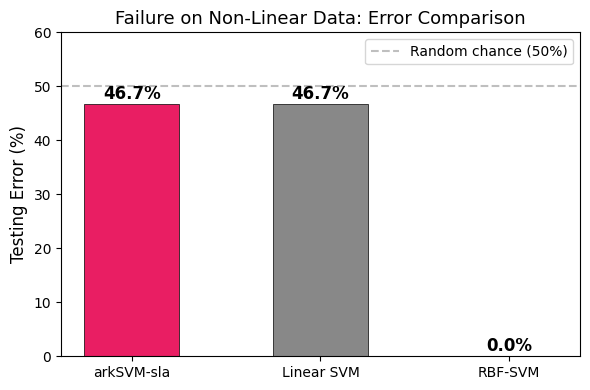

Saved to partB/results/failure_bar_chart.png


In [7]:
# ── Summary comparison bar chart ──

fig, ax = plt.subplots(figsize=(6, 4))
methods = ['arkSVM-sla', 'Linear SVM', 'RBF-SVM']
errors = [err_ark, err_lin, err_rbf]
colors = ['#E91E63', '#888888', '#4CAF50']

bars = ax.bar(methods, errors, color=colors, width=0.5, edgecolor='black', linewidth=0.5)
for bar, err in zip(bars, errors):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{err:.1f}%', ha='center', fontweight='bold', fontsize=12)

ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='Random chance (50%)')
ax.set_ylabel('Testing Error (%)', fontsize=12)
ax.set_title('Failure on Non-Linear Data: Error Comparison', fontsize=13)
ax.legend()
ax.set_ylim(0, 60)
plt.tight_layout()
plt.savefig('results/failure_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to partB/results/failure_bar_chart.png")

## Why the Method Fails — Connecting to Task 1.2 Assumptions

- **Result:** arkSVM fails entirely (47% error) while RBF-SVM succeeds (0%).
- **Why:** The dataset has a circular boundary, which violates **Assumption 1** (the classifier must be a straight line).
- **Role of Advice:** The method requires advice to be shaped as linear boundaries (polyhedrons). Shifting and tilting straight lines can never create a perfect circle.
- **Conclusion:** The method structurally cannot handle non-linear data. The paper acknowledges this by listing non-linear kernels as "future work" in Section 5.

### Suggested Modification

The method could be extended to handle non-linear decision boundaries by incorporating kernel functions into the KBSVM framework — as Fung et al. [5] already did for standard KBSVMs — and adapting the advice refinement terms F_i and f_i to operate in the kernel-induced feature space, where the circular boundary becomes linearly separable.